In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("/content/gdrive/MyDrive/stocks/tsla.us.txt")

In [ ]:
#Let's examine a few examples from our data.
data.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,2010-06-28,17.00,17.00,17.00,17.00,0,0
1,2010-06-29,19.00,25.00,17.54,23.89,18783276,0
2,2010-06-30,25.79,30.42,23.30,23.83,17194394,0
3,2010-07-01,25.00,25.92,20.27,21.96,8229863,0
4,2010-07-02,23.00,23.10,18.71,19.20,5141807,0


In [ ]:
print("Data Shape -->", data.shape)

Data Shape --> (1858, 7)


In [ ]:
data.describe()

,Open,High,Low,Close,Volume,OpenInt
count,1858.000000,1858.000000,1858.000000,1858.000000,1.858000e+03,1858.0
mean,150.389741,152.898737,147.688064,150.355047,4.416508e+06,0.0
std,107.071675,108.490099,105.481665,107.023737,4.244294e+06,0.0
min,16.140000,16.630000,8.030000,15.800000,0.000000e+00,0.0
25%,31.002500,31.732500,30.285000,31.112500,1.283324e+06,0.0
50%,184.440000,188.660000,181.450000,184.850000,3.421026e+06,0.0
75%,231.477500,235.375000,227.772500,230.920000,5.917672e+06,0.0
max,386.690000,389.610000,379.345000,385.000000,3.714989e+07,0.0


In [ ]:
print("Do you have a null column? \n", data.isna().sum())


Do you have a null column? 
 Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64


           Date   Close       MACD  Signal_Line         RSI
0    2010-06-28   17.00   0.000000     0.000000         NaN
1    2010-06-29   23.89   0.549630     0.109926  100.000000
2    2010-06-30   23.83   0.969201     0.281781   99.136691
3    2010-07-01   21.96   1.137707     0.452966   78.117914
4    2010-07-02   19.20   1.036590     0.569691   59.499136
...         ...     ...        ...          ...         ...
1853 2017-11-06  302.78 -11.999531    -8.274504   23.147115
1854 2017-11-07  306.05 -12.311572    -9.081918   22.653061
1855 2017-11-08  304.31 -12.554550    -9.776444   24.156692
1856 2017-11-09  302.99 -12.707144   -10.362584   25.661773
1857 2017-11-10  302.99 -12.681887   -10.826445   28.305495

[1858 rows x 5 columns]


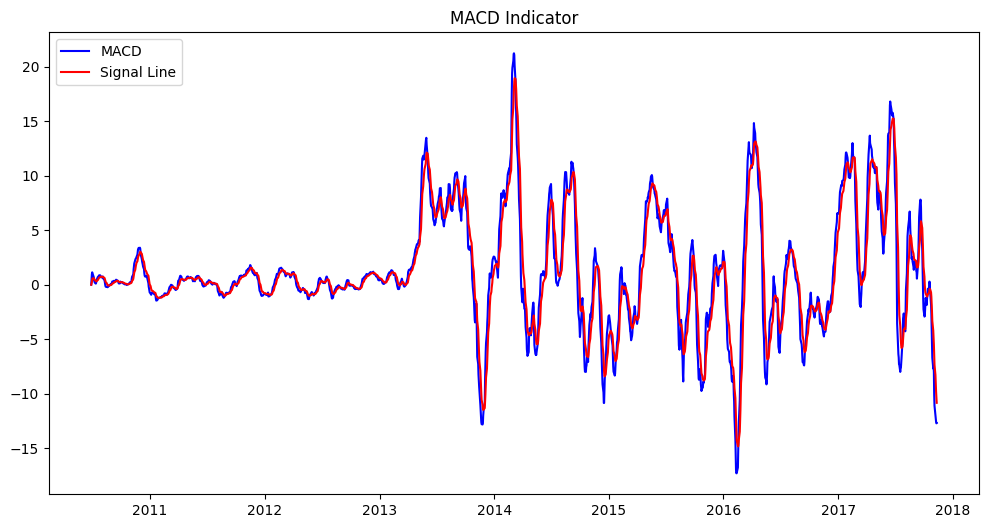

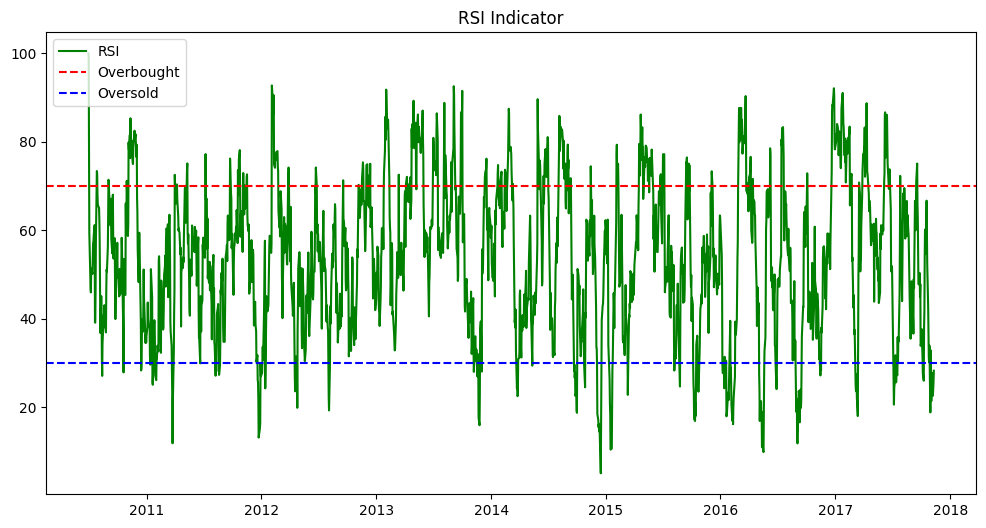

In [ ]:

# Ensure the 'Date' column is converted to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Calculate EMA (Exponential Moving Average) for MACD
short_window = 12
long_window = 26
signal_window = 9

data['EMA12'] = data['Close'].ewm(span=short_window, adjust=False).mean()
data['EMA26'] = data['Close'].ewm(span=long_window, adjust=False).mean()

# Calculate MACD and Signal Line
data['MACD'] = data['EMA12'] - data['EMA26']
data['Signal_Line'] = data['MACD'].ewm(span=signal_window, adjust=False).mean()

# Calculate RSI (Relative Strength Index)
window_length = 14

delta = data['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=window_length, min_periods=1).mean()
avg_loss = loss.rolling(window=window_length, min_periods=1).mean()

rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

# Display the data with calculated indicators
print(data[['Date', 'Close', 'MACD', 'Signal_Line', 'RSI']])

# Plot the MACD indicator
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['MACD'], label='MACD', color='blue')
plt.plot(data['Date'], data['Signal_Line'], label='Signal Line', color='red')
plt.legend(loc='upper left')
plt.title('MACD Indicator')
plt.show()

# Plot the RSI indicator
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['RSI'], label='RSI', color='green')
plt.axhline(70, linestyle='--', color='red', label='Overbought')
plt.axhline(30, linestyle='--', color='blue', label='Oversold')
plt.legend(loc='upper left')
plt.title('RSI Indicator')
plt.show()





In [ ]:
pip uninstall -y tensorflow

Found existing installation: tensorflow 2.17.1
Uninstalling tensorflow-2.17.1:
  Successfully uninstalled tensorflow-2.17.1


In [ ]:
pip install tensorflow-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 62.7 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.17.1
    Uninstalling tensorboard-2.17.1:
      Successfully uninstalled tensorboard-2.17.1


In [ ]:
#BERT for predicting next 1 day

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Input Length: 15, Epoch: 1, Loss: 0.11951293349266053
Input Length: 15, Epoch: 2, Loss: 0.08623470216989518
Input Length: 15, Epoch: 3, Loss: 0.08611071109771729


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 30, Epoch: 1, Loss: 0.18959926441311836
Input Length: 30, Epoch: 2, Loss: 0.10190499015152454
Input Length: 30, Epoch: 3, Loss: 0.09691385179758072


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 90, Epoch: 1, Loss: 0.1520886073509852
Input Length: 90, Epoch: 2, Loss: 0.10708119223515193
Input Length: 90, Epoch: 3, Loss: 0.09015892694393794


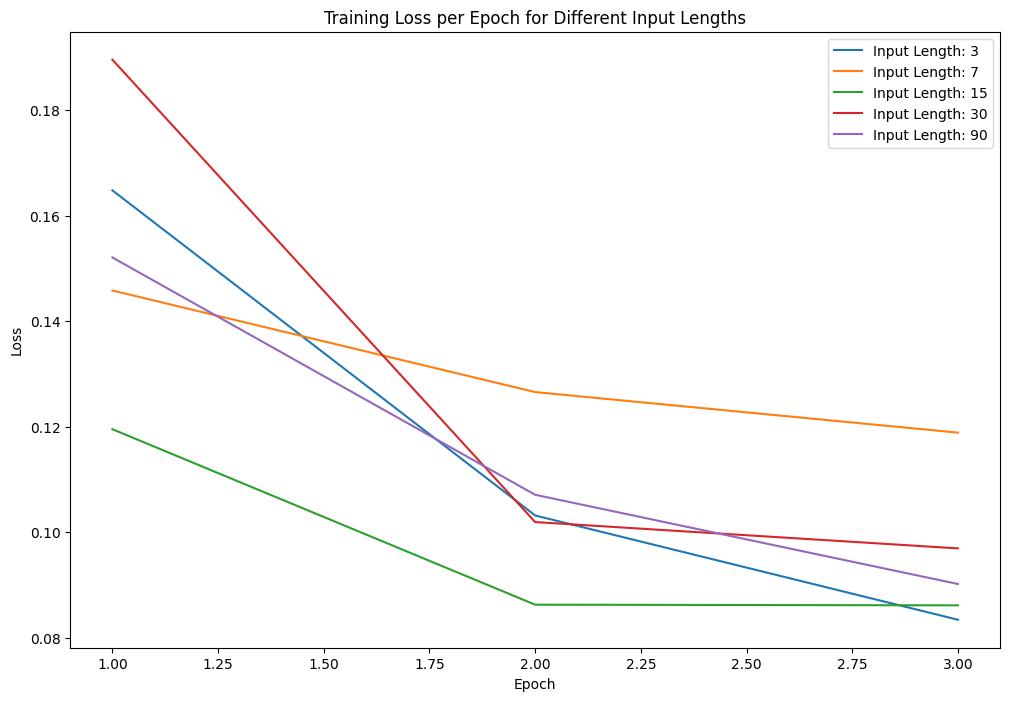

Input Length: 3, MSE: 0.09624351086635183
Input Length: 7, MSE: 0.10181001541538885
Input Length: 15, MSE: 0.1143583076751993
Input Length: 30, MSE: 0.12232927836197852
Input Length: 90, MSE: 0.11207982255776443


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv('/content/gdrive/MyDrive/stocks/processed_data.csv')  # Preprocessed data
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Sample 50% of the data to reduce training time
data = data.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Function to create input and output with different lengths
def create_time_series(data, input_days, target_days):
    X, y = [], []
    for i in range(len(data) - input_days - target_days + 1):
        X.append(data['Close'].iloc[i:i + input_days].values)
        y.append(data['Close'].iloc[i + input_days:i + input_days + target_days].values)
    return np.array(X), np.array(y)

# Settings
input_lengths = [3, 7, 15, 30, 90]  # Different input lengths
target_length = 1  # Predicting one day ahead
results = {}
training_loss_history = {}

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for input_length in input_lengths:
    # Create input and output data
    X, y = create_time_series(data, input_length, target_length)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Prepare data for DistilBERT
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            inputs = tokenizer(" ".join(map(str, self.X[idx])), padding='max_length', truncation=True, return_tensors="pt")
            return {
                'input_ids': inputs['input_ids'].squeeze(),
                'attention_mask': inputs['attention_mask'].squeeze(),
                'labels': torch.tensor(self.y[idx], dtype=torch.float)
            }

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Increased batch size
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # DistilBERT model
    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=target_length)
    model = model.to(device)

    # Freeze the model weights
    for param in model.distilbert.parameters():
        param.requires_grad = False  # Freeze the main DistilBERT weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)  # Higher learning rate
    loss_fn = torch.nn.MSELoss()

    # Train the model
    model.train()
    loss_history = []
    for epoch in range(3):  # Reduced number of epochs to 3
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            loss = outputs.loss
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f"Input Length: {input_length}, Epoch: {epoch + 1}, Loss: {avg_epoch_loss}")

    training_loss_history[input_length] = loss_history

    # Evaluate the model
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            y_pred.extend(outputs.logits.cpu().numpy())
            y_true.extend(batch['labels'].cpu().numpy())

    # Calculate MSE
    mse = mean_squared_error(y_true, y_pred)
    results[input_length] = mse

# Plot Loss for each input length
plt.figure(figsize=(12, 8))
for input_length, loss_history in training_loss_history.items():
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Input Length: {input_length}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch for Different Input Lengths')
plt.legend()
plt.show()

# Display final results
for input_length, mse in results.items():
    print(f"Input Length: {input_length}, MSE: {mse}")



In [ ]:
#BERT for predicting next 7 day

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Input Length: 15, Epoch: 1, Loss: 0.6511232376098632
Input Length: 15, Epoch: 2, Loss: 0.6446486949920655
Input Length: 15, Epoch: 3, Loss: 0.6590629816055298


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 30, Epoch: 1, Loss: 0.6646463423967361
Input Length: 30, Epoch: 2, Loss: 0.6655951887369156
Input Length: 30, Epoch: 3, Loss: 0.6574746668338776


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 90, Epoch: 1, Loss: 0.6707930763562521
Input Length: 90, Epoch: 2, Loss: 0.6622796058654785
Input Length: 90, Epoch: 3, Loss: 0.6561793684959412


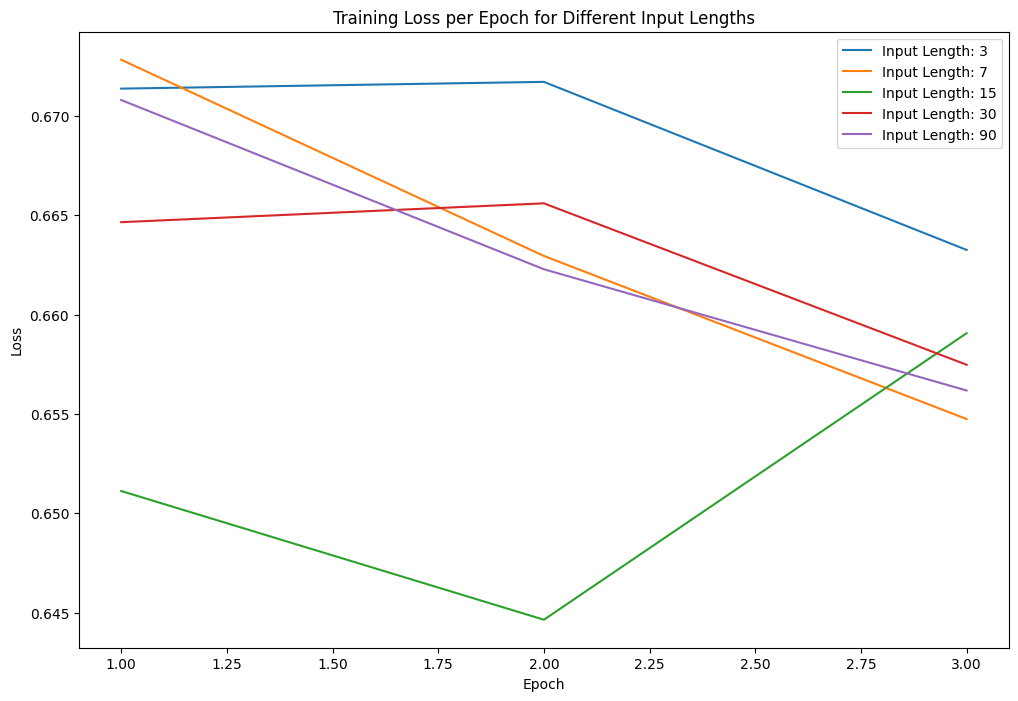

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv('/content/gdrive/MyDrive/stocks/processed_data.csv')  # Preprocessed data
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Sample 50% of the data to reduce training time
data = data.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Function to create input and output with different lengths
def create_time_series(data, input_days, target_days):
    X, y = [], []
    for i in range(len(data) - input_days - target_days + 1):
        X.append(data['Close'].iloc[i:i + input_days].values)
        y.append(data['Close'].iloc[i + input_days:i + input_days + target_days].values)
    return np.array(X), np.array(y)

# Settings
input_lengths = [3, 7, 15, 30, 90]  # Different input lengths
target_length = 7  # Predicting 7 day ahead
results = {}
training_loss_history = {}

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for input_length in input_lengths:
    # Create input and output data
    X, y = create_time_series(data, input_length, target_length)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Prepare data for DistilBERT
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            inputs = tokenizer(" ".join(map(str, self.X[idx])), padding='max_length', truncation=True, return_tensors="pt")
            return {
                'input_ids': inputs['input_ids'].squeeze(),
                'attention_mask': inputs['attention_mask'].squeeze(),
                'labels': torch.tensor(self.y[idx], dtype=torch.float)
            }

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Increased batch size
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # DistilBERT model
    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=target_length)
    model = model.to(device)

    # Freeze the model weights
    for param in model.distilbert.parameters():
        param.requires_grad = False  # Freeze the main DistilBERT weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)  # Higher learning rate
    loss_fn = torch.nn.MSELoss()

    # Train the model
    model.train()
    loss_history = []
    for epoch in range(3):  # Reduced number of epochs to 3
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            loss = outputs.loss
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f"Input Length: {input_length}, Epoch: {epoch + 1}, Loss: {avg_epoch_loss}")

    training_loss_history[input_length] = loss_history

    # Evaluate the model
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            y_pred.extend(outputs.logits.cpu().numpy())
            y_true.extend(batch['labels'].cpu().numpy())

    # Calculate MSE
    mse = mean_squared_error(y_true, y_pred)
    results[input_length] = mse

# Plot Loss for each input length
plt.figure(figsize=(12, 8))
for input_length, loss_history in training_loss_history.items():
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Input Length: {input_length}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch for Different Input Lengths')
plt.legend()
plt.show()

# Display final results
for input_length, mse in results.items():
    print(f"Input Length: {input_length}, MSE: {mse}")



In [ ]:
#BERT for predicting next 30 day

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 3, Epoch: 1, Loss: 0.6802013665437698
Input Length: 3, Epoch: 2, Loss: 0.6606388539075851
Input Length: 3, Epoch: 3, Loss: 0.6608099788427353


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 7, Epoch: 1, Loss: 0.6767406463623047
Input Length: 7, Epoch: 2, Loss: 0.6581333875656128
Input Length: 7, Epoch: 3, Loss: 0.6592044979333878


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 15, Epoch: 1, Loss: 0.6761045008897781
Input Length: 15, Epoch: 2, Loss: 0.6538086086511612
Input Length: 15, Epoch: 3, Loss: 0.655292809009552


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 30, Epoch: 1, Loss: 0.6717807799577713
Input Length: 30, Epoch: 2, Loss: 0.6530149132013321
Input Length: 30, Epoch: 3, Loss: 0.649376168847084


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 90, Epoch: 1, Loss: 0.6890235841274261
Input Length: 90, Epoch: 2, Loss: 0.6660170555114746
Input Length: 90, Epoch: 3, Loss: 0.6602992713451385


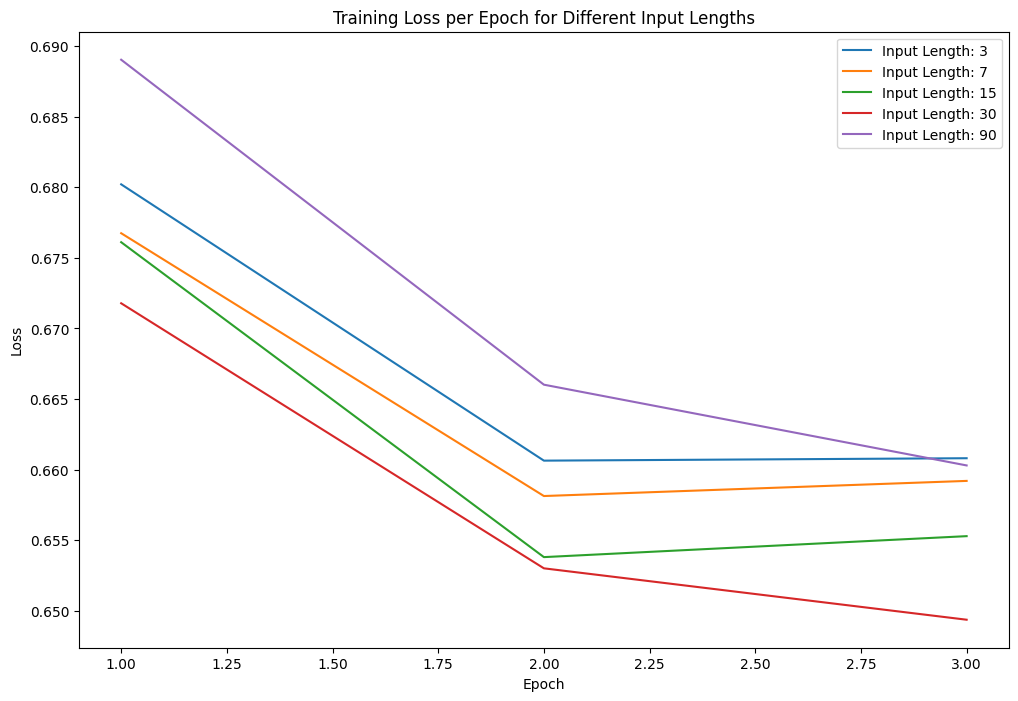

Input Length: 3, MSE: 1.1672089834489163
Input Length: 7, MSE: 1.1087089582096068
Input Length: 15, MSE: 1.3429469708387318
Input Length: 30, MSE: 1.3679832527317926
Input Length: 90, MSE: 1.2278182930316581


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv('/content/gdrive/MyDrive/stocks/processed_data.csv')  # Preprocessed data
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Sample 50% of the data to reduce training time
data = data.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Function to create input and output with different lengths
def create_time_series(data, input_days, target_days):
    X, y = [], []
    for i in range(len(data) - input_days - target_days + 1):
        X.append(data['Close'].iloc[i:i + input_days].values)
        y.append(data['Close'].iloc[i + input_days:i + input_days + target_days].values)
    return np.array(X), np.array(y)

# Settings
input_lengths = [3, 7, 15, 30, 90]  # Different input lengths
target_length = 30  # Predicting 30 day ahead
results = {}
training_loss_history = {}

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for input_length in input_lengths:
    # Create input and output data
    X, y = create_time_series(data, input_length, target_length)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Prepare data for DistilBERT
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            inputs = tokenizer(" ".join(map(str, self.X[idx])), padding='max_length', truncation=True, return_tensors="pt")
            return {
                'input_ids': inputs['input_ids'].squeeze(),
                'attention_mask': inputs['attention_mask'].squeeze(),
                'labels': torch.tensor(self.y[idx], dtype=torch.float)
            }

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Increased batch size
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # DistilBERT model
    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=target_length)
    model = model.to(device)

    # Freeze the model weights
    for param in model.distilbert.parameters():
        param.requires_grad = False  # Freeze the main DistilBERT weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)  # Higher learning rate
    loss_fn = torch.nn.MSELoss()

    # Train the model
    model.train()
    loss_history = []
    for epoch in range(3):  # Reduced number of epochs to 3
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            loss = outputs.loss
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f"Input Length: {input_length}, Epoch: {epoch + 1}, Loss: {avg_epoch_loss}")

    training_loss_history[input_length] = loss_history

    # Evaluate the model
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            y_pred.extend(outputs.logits.cpu().numpy())
            y_true.extend(batch['labels'].cpu().numpy())

    # Calculate MSE
    mse = mean_squared_error(y_true, y_pred)
    results[input_length] = mse

# Plot Loss for each input length
plt.figure(figsize=(12, 8))
for input_length, loss_history in training_loss_history.items():
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Input Length: {input_length}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch for Different Input Lengths')
plt.legend()
plt.show()

# Display final results
for input_length, mse in results.items():
    print(f"Input Length: {input_length}, MSE: {mse}")



In [ ]:
#LSTM for predicting next 1 day

Input Length: 3, Epoch: 1, Loss: 0.16383148233095804
Input Length: 3, Epoch: 2, Loss: 0.09379664078975718
Input Length: 3, Epoch: 3, Loss: 0.09033694118261337
Input Length: 3, Epoch: 4, Loss: 0.0898460013171037
Input Length: 3, Epoch: 5, Loss: 0.08917751318464677
Input Length: 3, Epoch: 6, Loss: 0.08700816488514344
Input Length: 3, Epoch: 7, Loss: 0.0879791509360075
Input Length: 3, Epoch: 8, Loss: 0.09023963970442613
Input Length: 3, Epoch: 9, Loss: 0.0891107462036113
Input Length: 3, Epoch: 10, Loss: 0.08852791196356218
Input Length: 7, Epoch: 1, Loss: 0.21053588908651602
Input Length: 7, Epoch: 2, Loss: 0.09012564368869948
Input Length: 7, Epoch: 3, Loss: 0.08763467714838359
Input Length: 7, Epoch: 4, Loss: 0.08825398301300795
Input Length: 7, Epoch: 5, Loss: 0.08734992340854976
Input Length: 7, Epoch: 6, Loss: 0.08720728754997253
Input Length: 7, Epoch: 7, Loss: 0.08730177014418271
Input Length: 7, Epoch: 8, Loss: 0.087861486427162
Input Length: 7, Epoch: 9, Loss: 0.087163208781377

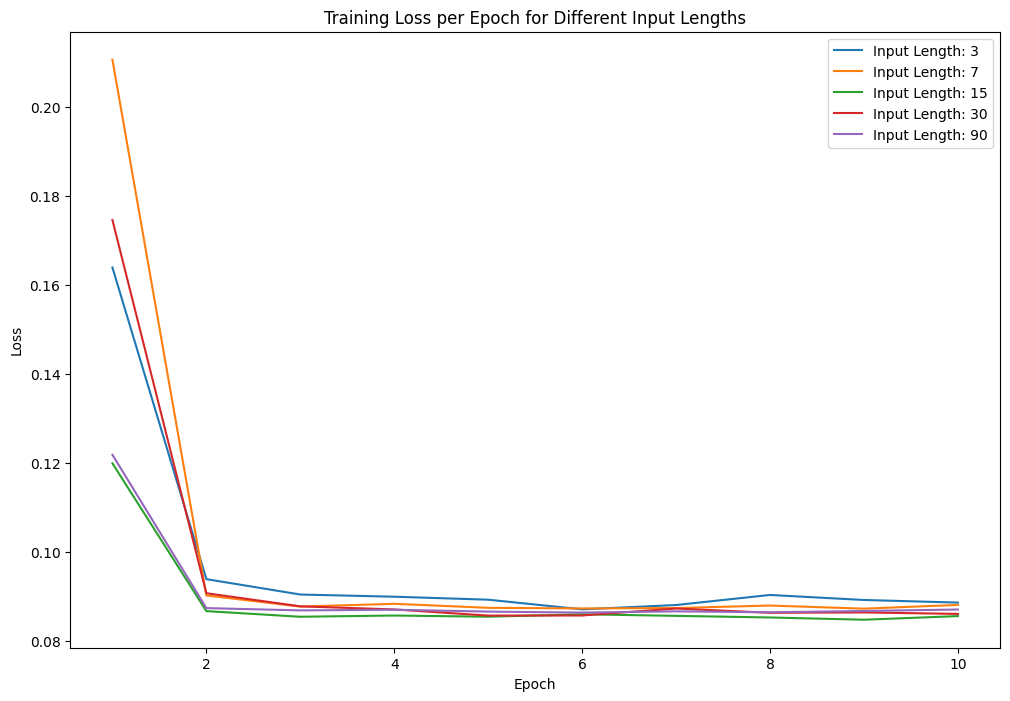


Final Results (MSE):
Input Length: 3, MSE: 0.0845
Input Length: 7, MSE: 0.0872
Input Length: 15, MSE: 0.0948
Input Length: 30, MSE: 0.0937
Input Length: 90, MSE: 0.0887


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv('/content/gdrive/MyDrive/stocks/processed_data.csv')  # Preprocessed data
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Sample 50% of the data to reduce training time
data = data.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Function to create input and output with different lengths
def create_time_series(data, input_days, target_days):
    X, y = [], []
    for i in range(len(data) - input_days - target_days + 1):
        X.append(data['Close'].iloc[i:i + input_days].values)
        y.append(data['Close'].iloc[i + input_days:i + input_days + target_days].values)
    return np.array(X), np.array(y)

# Settings
input_lengths = [3, 7, 15, 30, 90]  # Different input lengths
target_length = 1  # Predicting one day ahead
results = {}
training_loss_history = {}

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            'input': torch.tensor(self.X[idx], dtype=torch.float),
            'label': torch.tensor(self.y[idx], dtype=torch.float)
        }

# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Use the output of the last time step
        return out

for input_length in input_lengths:
    # Create input and output data
    X, y = create_time_series(data, input_length, target_length)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # LSTM model settings
    input_size = 1  # Single feature (closing price)
    hidden_size = 64
    num_layers = 2
    output_size = target_length

    model = LSTMModel(input_size, hidden_size, num_layers, output_size)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    loss_fn = nn.MSELoss()

    # Train the model
    model.train()
    loss_history = []
    for epoch in range(10):  # Increased number of epochs for better training
        epoch_loss = 0
        for batch in train_loader:
            inputs = batch['input'].unsqueeze(-1).to(device)  # Add feature dimension
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f"Input Length: {input_length}, Epoch: {epoch + 1}, Loss: {avg_epoch_loss}")

    training_loss_history[input_length] = loss_history

    # Evaluate the model
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch['input'].unsqueeze(-1).to(device)
            labels = batch['label'].to(device)
            outputs = model(inputs)
            y_pred.extend(outputs.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Calculate MSE
    mse = mean_squared_error(y_true, y_pred)
    results[input_length] = mse

# Plot Loss for each input length
plt.figure(figsize=(12, 8))
for input_length, loss_history in training_loss_history.items():
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Input Length: {input_length}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch for Different Input Lengths')
plt.legend()
plt.show()

# Display final results (MSE) for different input lengths
print("\nFinal Results (MSE):")
for input_length, mse in results.items():
    print(f"Input Length: {input_length}, MSE: {mse:.4f}")



In [ ]:
#LSTM for predicting next 7 day

Input Length: 3, Epoch: 1, Loss: 0.22529043905113055
Input Length: 3, Epoch: 2, Loss: 0.14431046176215875
Input Length: 3, Epoch: 3, Loss: 0.09054215770700703
Input Length: 3, Epoch: 4, Loss: 0.08778928382241208
Input Length: 3, Epoch: 5, Loss: 0.08725155177323715
Input Length: 3, Epoch: 6, Loss: 0.08725508820751439
Input Length: 3, Epoch: 7, Loss: 0.0871509093305339
Input Length: 3, Epoch: 8, Loss: 0.08713438005551048
Input Length: 3, Epoch: 9, Loss: 0.0871457739368729
Input Length: 3, Epoch: 10, Loss: 0.08711309828188109
Input Length: 7, Epoch: 1, Loss: 0.20571825750496076
Input Length: 7, Epoch: 2, Loss: 0.10231243106334106
Input Length: 7, Epoch: 3, Loss: 0.0881717758982078
Input Length: 7, Epoch: 4, Loss: 0.08735672999983249
Input Length: 7, Epoch: 5, Loss: 0.08734942324783491
Input Length: 7, Epoch: 6, Loss: 0.0872450629654138
Input Length: 7, Epoch: 7, Loss: 0.08728528929793317
Input Length: 7, Epoch: 8, Loss: 0.08722055962552196
Input Length: 7, Epoch: 9, Loss: 0.08714420899100

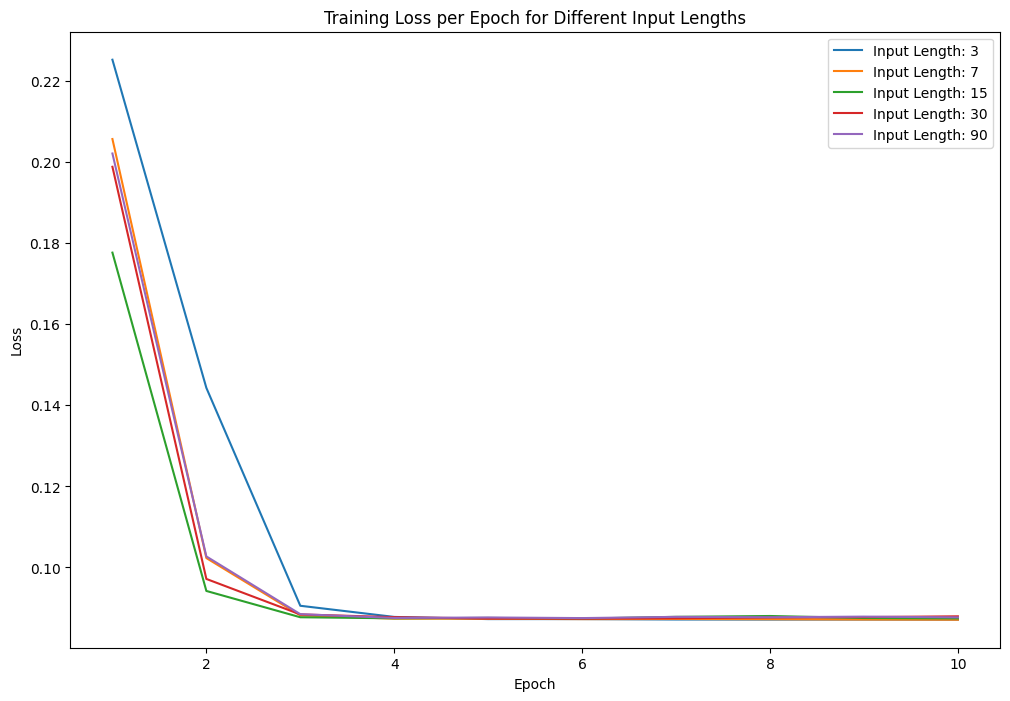


Final Results (MSE):
Input Length: 3, MSE: 0.0864
Input Length: 7, MSE: 0.0857
Input Length: 15, MSE: 0.0848
Input Length: 30, MSE: 0.0869
Input Length: 90, MSE: 0.0838


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv('/content/gdrive/MyDrive/stocks/processed_data.csv')  # Preprocessed data
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Sample 50% of the data to reduce training time
data = data.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Function to create input and output with different lengths
def create_time_series(data, input_days, target_days):
    X, y = [], []
    for i in range(len(data) - input_days - target_days + 1):
        X.append(data['Close'].iloc[i:i + input_days].values)
        y.append(data['Close'].iloc[i + input_days:i + input_days + target_days].values)
    return np.array(X), np.array(y)

# Settings
input_lengths = [3, 7, 15, 30, 90]  # Different input lengths
target_length = 7  # Predicting 7 day ahead
results = {}
training_loss_history = {}

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            'input': torch.tensor(self.X[idx], dtype=torch.float),
            'label': torch.tensor(self.y[idx], dtype=torch.float)
        }

# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Use the output of the last time step
        return out

for input_length in input_lengths:
    # Create input and output data
    X, y = create_time_series(data, input_length, target_length)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # LSTM model settings
    input_size = 1  # Single feature (closing price)
    hidden_size = 64
    num_layers = 2
    output_size = target_length

    model = LSTMModel(input_size, hidden_size, num_layers, output_size)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    loss_fn = nn.MSELoss()

    # Train the model
    model.train()
    loss_history = []
    for epoch in range(10):  # Increased number of epochs for better training
        epoch_loss = 0
        for batch in train_loader:
            inputs = batch['input'].unsqueeze(-1).to(device)  # Add feature dimension
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f"Input Length: {input_length}, Epoch: {epoch + 1}, Loss: {avg_epoch_loss}")

    training_loss_history[input_length] = loss_history

    # Evaluate the model
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch['input'].unsqueeze(-1).to(device)
            labels = batch['label'].to(device)
            outputs = model(inputs)
            y_pred.extend(outputs.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Calculate MSE
    mse = mean_squared_error(y_true, y_pred)
    results[input_length] = mse

# Plot Loss for each input length
plt.figure(figsize=(12, 8))
for input_length, loss_history in training_loss_history.items():
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Input Length: {input_length}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch for Different Input Lengths')
plt.legend()
plt.show()

# Display final results (MSE) for different input lengths
print("\nFinal Results (MSE):")
for input_length, mse in results.items():
    print(f"Input Length: {input_length}, MSE: {mse:.4f}")



In [ ]:
#LSTM for predicting next 30 day

Input Length: 3, Epoch: 1, Loss: 0.2023385737253272
Input Length: 3, Epoch: 2, Loss: 0.14511607846488123
Input Length: 3, Epoch: 3, Loss: 0.09436918147232222
Input Length: 3, Epoch: 4, Loss: 0.08748356382484021
Input Length: 3, Epoch: 5, Loss: 0.08703942078611125
Input Length: 3, Epoch: 6, Loss: 0.08705116095750229
Input Length: 3, Epoch: 7, Loss: 0.08692200903011404
Input Length: 3, Epoch: 8, Loss: 0.08699805030356282
Input Length: 3, Epoch: 9, Loss: 0.08673574257156123
Input Length: 3, Epoch: 10, Loss: 0.08678348945534747
Input Length: 7, Epoch: 1, Loss: 0.198590821546057
Input Length: 7, Epoch: 2, Loss: 0.11105919564547746
Input Length: 7, Epoch: 3, Loss: 0.08772622534762257
Input Length: 7, Epoch: 4, Loss: 0.08669633094383322
Input Length: 7, Epoch: 5, Loss: 0.0868665776822878
Input Length: 7, Epoch: 6, Loss: 0.08669441906006439
Input Length: 7, Epoch: 7, Loss: 0.0868020861045174
Input Length: 7, Epoch: 8, Loss: 0.08675237777440445
Input Length: 7, Epoch: 9, Loss: 0.086561467660510

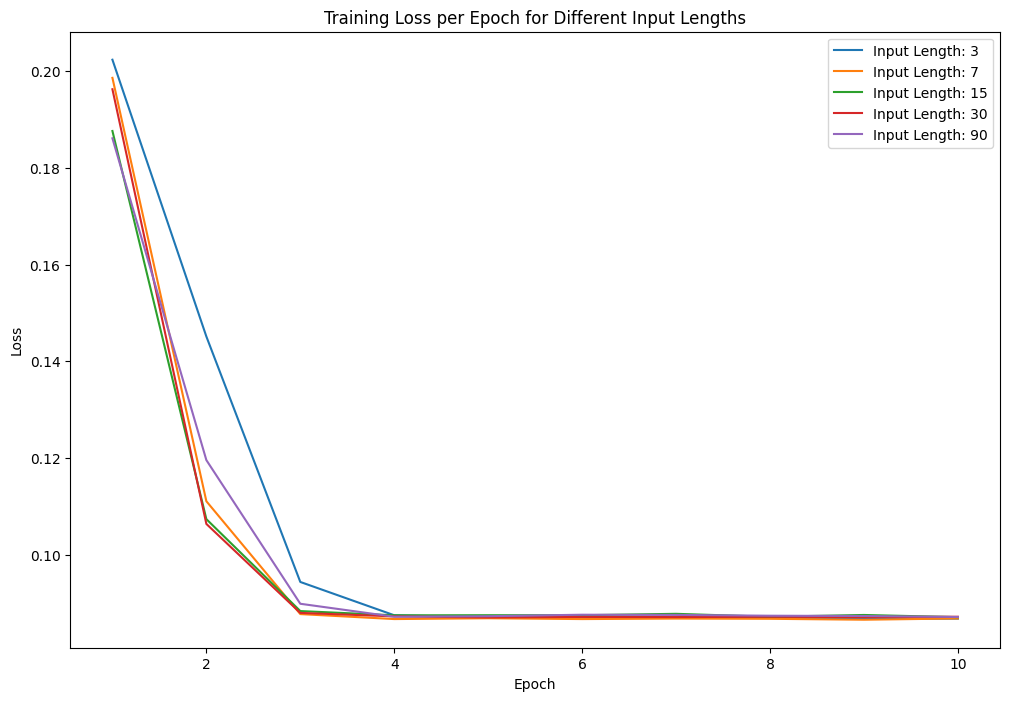


Final Results (MSE):
Input Length: 3, MSE: 0.0863
Input Length: 7, MSE: 0.0871
Input Length: 15, MSE: 0.0853
Input Length: 30, MSE: 0.0859
Input Length: 90, MSE: 0.0855


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv('/content/gdrive/MyDrive/stocks/processed_data.csv')  # Preprocessed data
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Sample 50% of the data to reduce training time
data = data.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Function to create input and output with different lengths
def create_time_series(data, input_days, target_days):
    X, y = [], []
    for i in range(len(data) - input_days - target_days + 1):
        X.append(data['Close'].iloc[i:i + input_days].values)
        y.append(data['Close'].iloc[i + input_days:i + input_days + target_days].values)
    return np.array(X), np.array(y)

# Settings
input_lengths = [3, 7, 15, 30, 90]  # Different input lengths
target_length = 30  # Predicting 30 day ahead
results = {}
training_loss_history = {}

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            'input': torch.tensor(self.X[idx], dtype=torch.float),
            'label': torch.tensor(self.y[idx], dtype=torch.float)
        }

# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Use the output of the last time step
        return out

for input_length in input_lengths:
    # Create input and output data
    X, y = create_time_series(data, input_length, target_length)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # LSTM model settings
    input_size = 1  # Single feature (closing price)
    hidden_size = 64
    num_layers = 2
    output_size = target_length

    model = LSTMModel(input_size, hidden_size, num_layers, output_size)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    loss_fn = nn.MSELoss()

    # Train the model
    model.train()
    loss_history = []
    for epoch in range(10):  # Increased number of epochs for better training
        epoch_loss = 0
        for batch in train_loader:
            inputs = batch['input'].unsqueeze(-1).to(device)  # Add feature dimension
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f"Input Length: {input_length}, Epoch: {epoch + 1}, Loss: {avg_epoch_loss}")

    training_loss_history[input_length] = loss_history

    # Evaluate the model
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch['input'].unsqueeze(-1).to(device)
            labels = batch['label'].to(device)
            outputs = model(inputs)
            y_pred.extend(outputs.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Calculate MSE
    mse = mean_squared_error(y_true, y_pred)
    results[input_length] = mse

# Plot Loss for each input length
plt.figure(figsize=(12, 8))
for input_length, loss_history in training_loss_history.items():
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Input Length: {input_length}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch for Different Input Lengths')
plt.legend()
plt.show()

# Display final results (MSE) for different input lengths
print("\nFinal Results (MSE):")
for input_length, mse in results.items():
    print(f"Input Length: {input_length}, MSE: {mse:.4f}")



In [ ]:
#RoBERTa for predicting next 1 day

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Input Length: 15, Epoch: 1, Loss: 0.1188416714253633
Input Length: 15, Epoch: 2, Loss: 0.09124309310446614
Input Length: 15, Epoch: 3, Loss: 0.09531512807892717


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 30, Epoch: 1, Loss: 0.11114840144696443
Input Length: 30, Epoch: 2, Loss: 0.09605397219243257
Input Length: 30, Epoch: 3, Loss: 0.09943487883909889


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 90, Epoch: 1, Loss: 0.13114687516575768
Input Length: 90, Epoch: 2, Loss: 0.10041046532846633
Input Length: 90, Epoch: 3, Loss: 0.09168915734404609


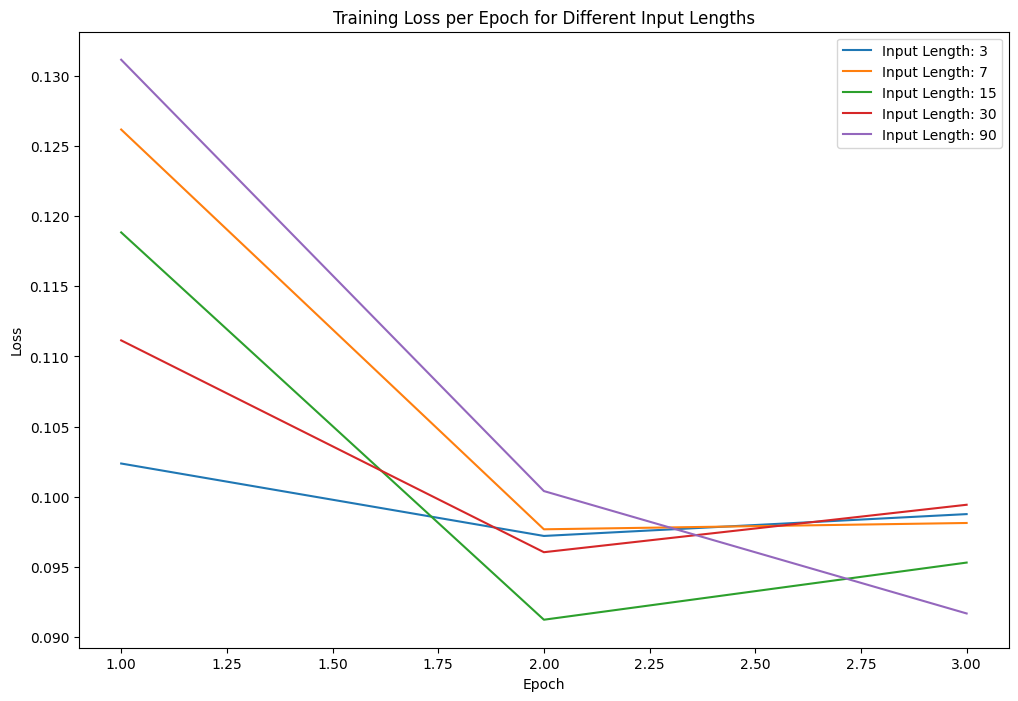


Final Results (MSE):
Input Length: 3, MSE: 0.0842404052713824
Input Length: 7, MSE: 0.09154357840785729
Input Length: 15, MSE: 0.09802820393970321
Input Length: 30, MSE: 0.11172072488821153
Input Length: 90, MSE: 0.0885475634154334


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv('/content/gdrive/MyDrive/stocks/processed_data.csv')  # Preprocessed data
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Sample 50% of the data to reduce training time
data = data.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Function to create input and output sequences of varying lengths
def create_time_series(data, input_days, target_days):
    X, y = [], []
    for i in range(len(data) - input_days - target_days + 1):
        X.append(data['Close'].iloc[i:i + input_days].values)
        y.append(data['Close'].iloc[i + input_days:i + input_days + target_days].values)
    return np.array(X), np.array(y)

# Settings
input_lengths = [3, 7, 15, 30, 90]  # Different input lengths
target_length = 1  # Predicting one day ahead
results = {}
training_loss_history = {}

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for input_length in input_lengths:
    # Create input and output sequences
    X, y = create_time_series(data, input_length, target_length)

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Prepare data for RoBERTa
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            inputs = tokenizer(" ".join(map(str, self.X[idx])), padding='max_length', truncation=True, return_tensors="pt")
            return {
                'input_ids': inputs['input_ids'].squeeze(),
                'attention_mask': inputs['attention_mask'].squeeze(),
                'labels': torch.tensor(self.y[idx], dtype=torch.float)
            }

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Initialize RoBERTa model
    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=target_length)
    model = model.to(device)

    # Freeze the weights of the RoBERTa base model
    for param in model.roberta.parameters():
        param.requires_grad = False  # Freeze the base weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    loss_fn = torch.nn.MSELoss()

    # Train the model
    model.train()
    loss_history = []
    for epoch in range(3):
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            loss = outputs.loss
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f"Input Length: {input_length}, Epoch: {epoch + 1}, Loss: {avg_epoch_loss}")

    training_loss_history[input_length] = loss_history

    # Evaluate the model
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            y_pred.extend(outputs.logits.cpu().numpy())
            y_true.extend(batch['labels'].cpu().numpy())

    # Calculate MSE
    mse = mean_squared_error(y_true, y_pred)
    results[input_length] = mse

# Plot loss for each input length
plt.figure(figsize=(12, 8))
for input_length, loss_history in training_loss_history.items():
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Input Length: {input_length}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch for Different Input Lengths')
plt.legend()
plt.show()

# Display final results
print("\nFinal Results (MSE):")
for input_length, mse in results.items():
    print(f"Input Length: {input_length}, MSE: {mse}")



In [ ]:
#RoBERTa for predicting next 7 day

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 3, Epoch: 1, Loss: 0.6770365953445434
Input Length: 3, Epoch: 2, Loss: 0.6746449589729309
Input Length: 3, Epoch: 3, Loss: 0.6635668754577637


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 7, Epoch: 1, Loss: 0.6822607755661011
Input Length: 7, Epoch: 2, Loss: 0.666103196144104
Input Length: 7, Epoch: 3, Loss: 0.6647280097007752


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 15, Epoch: 1, Loss: 0.6603471279144287
Input Length: 15, Epoch: 2, Loss: 0.6725613594055175
Input Length: 15, Epoch: 3, Loss: 0.6720483064651489


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 30, Epoch: 1, Loss: 0.6819263994693756
Input Length: 30, Epoch: 2, Loss: 0.6597798019647598
Input Length: 30, Epoch: 3, Loss: 0.6650568395853043


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 90, Epoch: 1, Loss: 0.6703968246777853
Input Length: 90, Epoch: 2, Loss: 0.6901647249857584
Input Length: 90, Epoch: 3, Loss: 0.6620846390724182


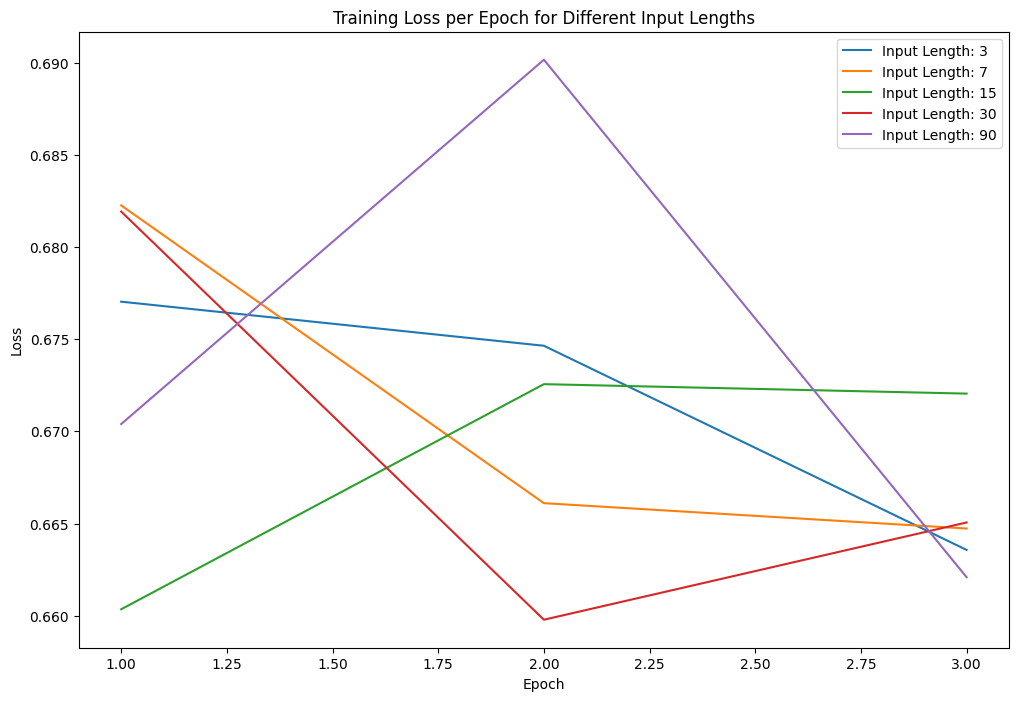


Final Results (MSE):
Input Length: 3, MSE: 0.7115779135353707
Input Length: 7, MSE: 0.7703081307264299
Input Length: 15, MSE: 0.8736545373487702
Input Length: 30, MSE: 0.9353704754591808
Input Length: 90, MSE: 0.9409487330854713


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv('/content/gdrive/MyDrive/stocks/processed_data.csv')  # Preprocessed data
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Sample 50% of the data to reduce training time
data = data.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Function to create input and output sequences of varying lengths
def create_time_series(data, input_days, target_days):
    X, y = [], []
    for i in range(len(data) - input_days - target_days + 1):
        X.append(data['Close'].iloc[i:i + input_days].values)
        y.append(data['Close'].iloc[i + input_days:i + input_days + target_days].values)
    return np.array(X), np.array(y)

# Settings
input_lengths = [3, 7, 15, 30, 90]  # Different input lengths
target_length = 7  # Predicting 7 day ahead
results = {}
training_loss_history = {}

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for input_length in input_lengths:
    # Create input and output sequences
    X, y = create_time_series(data, input_length, target_length)

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Prepare data for RoBERTa
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            inputs = tokenizer(" ".join(map(str, self.X[idx])), padding='max_length', truncation=True, return_tensors="pt")
            return {
                'input_ids': inputs['input_ids'].squeeze(),
                'attention_mask': inputs['attention_mask'].squeeze(),
                'labels': torch.tensor(self.y[idx], dtype=torch.float)
            }

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Initialize RoBERTa model
    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=target_length)
    model = model.to(device)

    # Freeze the weights of the RoBERTa base model
    for param in model.roberta.parameters():
        param.requires_grad = False  # Freeze the base weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    loss_fn = torch.nn.MSELoss()

    # Train the model
    model.train()
    loss_history = []
    for epoch in range(3):
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            loss = outputs.loss
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f"Input Length: {input_length}, Epoch: {epoch + 1}, Loss: {avg_epoch_loss}")

    training_loss_history[input_length] = loss_history

    # Evaluate the model
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            y_pred.extend(outputs.logits.cpu().numpy())
            y_true.extend(batch['labels'].cpu().numpy())

    # Calculate MSE
    mse = mean_squared_error(y_true, y_pred)
    results[input_length] = mse

# Plot loss for each input length
plt.figure(figsize=(12, 8))
for input_length, loss_history in training_loss_history.items():
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Input Length: {input_length}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch for Different Input Lengths')
plt.legend()
plt.show()

# Display final results
print("\nFinal Results (MSE):")
for input_length, mse in results.items():
    print(f"Input Length: {input_length}, MSE: {mse}")


In [ ]:
#RoBERTa for predicting next 30 day

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 3, Epoch: 1, Loss: 0.6801221519708633
Input Length: 3, Epoch: 2, Loss: 0.6627086699008942
Input Length: 3, Epoch: 3, Loss: 0.6643548756837845


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 7, Epoch: 1, Loss: 0.6771054267883301
Input Length: 7, Epoch: 2, Loss: 0.6640748977661133
Input Length: 7, Epoch: 3, Loss: 0.6676388680934906


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 15, Epoch: 1, Loss: 0.676585465669632
Input Length: 15, Epoch: 2, Loss: 0.6584016382694244
Input Length: 15, Epoch: 3, Loss: 0.6639309972524643


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 30, Epoch: 1, Loss: 0.669235348701477
Input Length: 30, Epoch: 2, Loss: 0.6564244627952576
Input Length: 30, Epoch: 3, Loss: 0.6585002839565277


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Length: 90, Epoch: 1, Loss: 0.6858243644237518
Input Length: 90, Epoch: 2, Loss: 0.6672139465808868
Input Length: 90, Epoch: 3, Loss: 0.6627884805202484


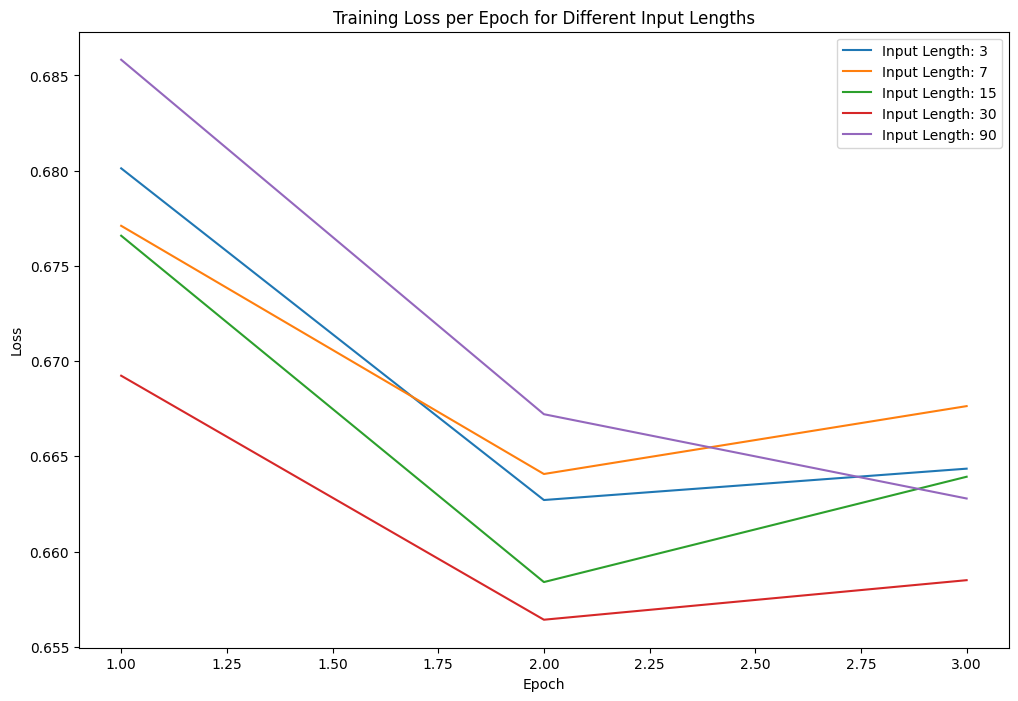


Final Results (MSE):
Input Length: 3, MSE: 1.050149863080413
Input Length: 7, MSE: 0.9419036517436097
Input Length: 15, MSE: 1.1778039365611763
Input Length: 30, MSE: 1.233239028775089
Input Length: 90, MSE: 0.9904619682836617


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv('/content/gdrive/MyDrive/stocks/processed_data.csv')  # Preprocessed data
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Sample 50% of the data to reduce training time
data = data.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Function to create input and output sequences of varying lengths
def create_time_series(data, input_days, target_days):
    X, y = [], []
    for i in range(len(data) - input_days - target_days + 1):
        X.append(data['Close'].iloc[i:i + input_days].values)
        y.append(data['Close'].iloc[i + input_days:i + input_days + target_days].values)
    return np.array(X), np.array(y)

# Settings
input_lengths = [3, 7, 15, 30, 90]  # Different input lengths
target_length = 30  # Predicting 30 day ahead
results = {}
training_loss_history = {}

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for input_length in input_lengths:
    # Create input and output sequences
    X, y = create_time_series(data, input_length, target_length)

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Prepare data for RoBERTa
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            inputs = tokenizer(" ".join(map(str, self.X[idx])), padding='max_length', truncation=True, return_tensors="pt")
            return {
                'input_ids': inputs['input_ids'].squeeze(),
                'attention_mask': inputs['attention_mask'].squeeze(),
                'labels': torch.tensor(self.y[idx], dtype=torch.float)
            }

    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Initialize RoBERTa model
    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=target_length)
    model = model.to(device)

    # Freeze the weights of the RoBERTa base model
    for param in model.roberta.parameters():
        param.requires_grad = False  # Freeze the base weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    loss_fn = torch.nn.MSELoss()

    # Train the model
    model.train()
    loss_history = []
    for epoch in range(3):
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            loss = outputs.loss
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f"Input Length: {input_length}, Epoch: {epoch + 1}, Loss: {avg_epoch_loss}")

    training_loss_history[input_length] = loss_history

    # Evaluate the model
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            y_pred.extend(outputs.logits.cpu().numpy())
            y_true.extend(batch['labels'].cpu().numpy())

    # Calculate MSE
    mse = mean_squared_error(y_true, y_pred)
    results[input_length] = mse

# Plot loss for each input length
plt.figure(figsize=(12, 8))
for input_length, loss_history in training_loss_history.items():
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Input Length: {input_length}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch for Different Input Lengths')
plt.legend()
plt.show()

# Display final results
print("\nFinal Results (MSE):")
for input_length, mse in results.items():
    print(f"Input Length: {input_length}, MSE: {mse}")

